<a href="https://colab.research.google.com/github/AvaniRathi/Machine-Learning/blob/main/ML_Pipeline_predict_news_popularity_on_sm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

Dataset Loaded ✅
    IDLink                                              Title  \
0  99248.0   Obama Lays Wreath at Arlington National Cemetery   
1  10423.0        A Look at the Health of the Chinese Economy   
2  18828.0   Nouriel Roubini: Global Economy Not Back to 2008   
3  27788.0                          Finland GDP Expands In Q4   
4  27789.0  Tourism, govt spending buoys Thai economy in J...   

                                            Headline  \
0  Obama Lays Wreath at Arlington National Cemete...   
1  Tim Haywood, investment director business-unit...   
2  Nouriel Roubini, NYU professor and chairman at...   
3  Finland's economy expanded marginally in the t...   
4  Tourism and public spending continued to boost...   

                                     Source    Topic          PublishDate  \
0                                 USA TODAY    obama  2002-04-02 00:00:00   
1                                 Bloomberg  economy  2008-09-20 00:00:00   
2                       

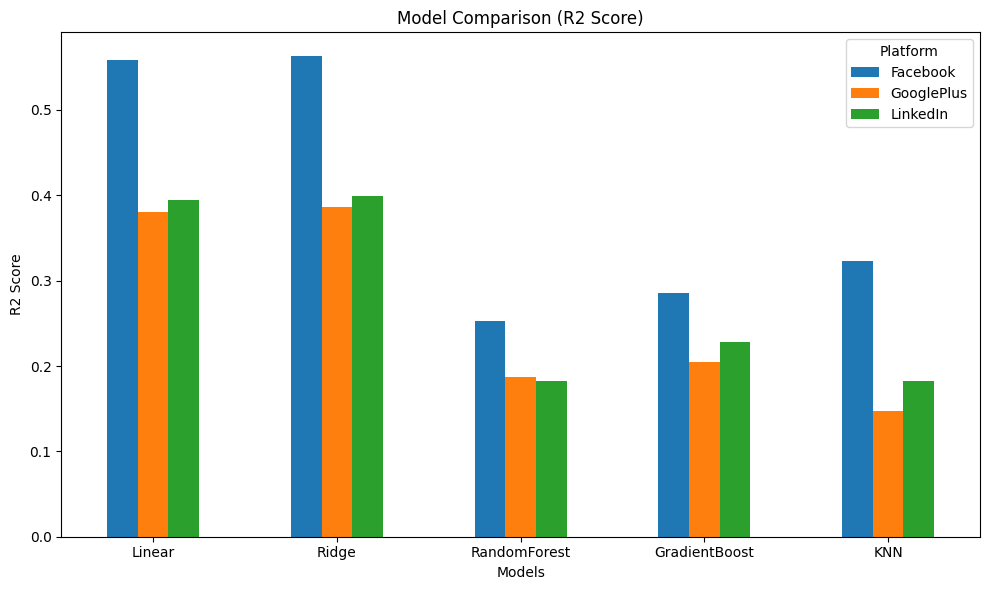

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

# ===============================
# LOAD DATA
# ===============================
df = pd.read_csv("News_Final.csv")

print("Dataset Loaded ✅")
print(df.head())

# ===============================
# DATA CLEANING
# ===============================

# Missing values remove
df = df.dropna()

# Date convert
df['PublishDate'] = pd.to_datetime(df['PublishDate'], errors='coerce')
df = df.dropna(subset=['PublishDate'])

df = df.drop(columns=['Title', 'Headline'], errors='ignore')
# Date features
df['hour'] = df['PublishDate'].dt.hour
df['day'] = df['PublishDate'].dt.dayofweek

df = df[(df['Facebook'] != -1) &
        (df['GooglePlus'] != -1) &
        (df['LinkedIn'] != -1)]

df['Facebook'] = np.log1p(df['Facebook'])
df['GooglePlus'] = np.log1p(df['GooglePlus'])
df['LinkedIn'] = np.log1p(df['LinkedIn'])

# Drop original date
df = df.drop(columns=['PublishDate'])

# ===============================
# FEATURES & TARGET
# ===============================
targets = ['Facebook', 'GooglePlus', 'LinkedIn']
X = df.drop(columns=targets)

categorical_cols = ['Topic', 'Source']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# ===============================
# PREPROCESSING PIPELINE
# ===============================
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# ===============================
# MODELS
# ===============================
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "RandomForest": RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    "GradientBoost": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}

# ===============================
# TRAIN + EVALUATE
# ===============================
r2_scores = {}

for target in targets:
    print(f"\n==============================")
    print(f"TARGET: {target}")
    print(f"==============================")

    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    r2_scores[target] = {}

    for name, model in models.items():

        pipe = Pipeline([
            ('prep', preprocessor),
            ('model', model)
        ])

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        r2_scores[target][name] = r2

        print(f"\n{name}")
        print(f"MAE: {mae:.2f}")
        print(f"RMSE: {rmse:.2f}")
        print(f"R2: {r2:.4f}")

# ===============================
# GRAPH (R2 COMPARISON)
# ===============================

r2_df = pd.DataFrame(r2_scores)

r2_df.plot(kind='bar', figsize=(10,6))

plt.title("Model Comparison (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.xticks(rotation=0)
plt.legend(title="Platform")

plt.tight_layout()
plt.show()